In [ ]:
!pip install -U transformers

[Qwen/Qwen2.5-0.5B-Instruct](https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct/tree/main)

## Tokenizer分词器

登录到HuggingFace 方便下载模型

In [ ]:
from huggingface_hub import login
from google.colab import userdata

# login(new_session=False) #你自己執行時請把這行改成 login(token="YOUR Hugging Face Token", new_session=False)
login(token=userdata.get('huggingface'))

1. AutoTokenizer 用于加载特定于预训练模型的
2. Tokenizer，而 AutoModelForCausalLM 通常用于加载模型本身

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
# model_name = "Qwen/Qwen2.5-0.5B-Instruct"
model_name = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name, use_auth_token=True)
print("語言模型有多少不同的 Token 可以選擇：", tokenizer.vocab_size)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


語言模型有多少不同的 Token 可以選擇： 151643


将编号转为对应的文字

In [ ]:
tokenizer.decode([99466,52801])

'大家好'

In [ ]:
text = "我在深圳图书馆北馆学习大模型"
tokens = tokenizer.encode(text,add_special_tokens=False) # 将文字转化为token id，加上 add_special_tokens=False 可以避免加上代表起始的符号
print(text ,"->", tokens)

我在深圳图书馆北馆学习大模型 -> [104786, 101119, 106036, 48309, 99682, 100134, 26288, 104949]


In [ ]:
print(f"{tokens} -> {tokenizer.decode(tokens)}")

[104786, 101119, 106036, 48309, 99682, 100134, 26288, 104949] -> 我在深圳图书馆北馆学习大模型


In [ ]:
tokens = tokenizer.encode(text,add_special_tokens=True)
print(tokens)

[104786, 101119, 106036, 48309, 99682, 100134, 26288, 104949]


### 特殊 Token 的作用示例

让我们看看这个 `tokenizer` 有哪些特殊 Token，以及 `add_special_tokens` 如何影响编码和解码的结果。

In [ ]:
# 打印 tokenizer 的所有特殊 Token
print("当前 tokenizer 的所有特殊 Token：", tokenizer.all_special_tokens)
print("特殊 Token 到 ID 的映射：", tokenizer.special_tokens_map)

# 定义一个用于演示的文本
demo_text = "你好，世界！"

# 1. 不添加特殊 Token 进行编码和解码
tokens_no_special = tokenizer.encode(demo_text, add_special_tokens=False)
decoded_no_special = tokenizer.decode(tokens_no_special)

print(f"\n原始文本: {demo_text}")
print(f"不加特殊 Token 的编码: {tokens_no_special}")
print(f"不加特殊 Token 的解码: '{decoded_no_special}'")

# 2. 添加特殊 Token 进行编码和解码
tokens_with_special = tokenizer.encode(demo_text, add_special_tokens=True)
decoded_with_special = tokenizer.decode(tokens_with_special)

print(f"\n加特殊 Token 的编码: {tokens_with_special}")
print(f"加特殊 Token 的解码: '{decoded_with_special}'")

# 比较两个编码的长度和内容
print(f"\n编码长度 (无特殊 Token): {len(tokens_no_special)}")
print(f"编码长度 (有特殊 Token): {len(tokens_with_special)}")
print(f"两个编码序列是否相同: {tokens_no_special == tokens_with_special}")


当前 tokenizer 的所有特殊 Token： ['<|im_end|>', '<|endoftext|>', '<|im_start|>', '<|object_ref_start|>', '<|object_ref_end|>', '<|box_start|>', '<|box_end|>', '<|quad_start|>', '<|quad_end|>', '<|vision_start|>', '<|vision_end|>', '<|vision_pad|>', '<|image_pad|>', '<|video_pad|>']
特殊 Token 到 ID 的映射： {'eos_token': '<|im_end|>', 'pad_token': '<|endoftext|>'}

原始文本: 你好，世界！
不加特殊 Token 的编码: [108386, 3837, 99489, 6313]
不加特殊 Token 的解码: '你好，世界！'

加特殊 Token 的编码: [108386, 3837, 99489, 6313]
加特殊 Token 的解码: '你好，世界！'

编码长度 (无特殊 Token): 4
编码长度 (有特殊 Token): 4
两个编码序列是否相同: True


### 特殊 Token 总结

1.  **`add_special_tokens=False`**：
    *   只对原始文本内容进行 Token 化，不添加任何模型所需的特殊标记。
    *   适用于仅需要文本内容 Token 化，不用于模型输入（例如，文本分析或长度计算）的场景。

2.  **`add_special_tokens=True`**（默认值）：
    *   在 Token 序列中加入模型预定义的特殊 Token，这些 Token 对模型理解输入结构至关重要。
    *   例如：序列开始 Token (如 `[CLS]` 或 `<s>`)、序列结束 Token (如 `[SEP]` 或 `</s>`)、填充 Token (`[PAD]`) 等。
    *   **Qwen Tokenizer 的行为特例**：对于 Qwen 这类模型，在处理简单的单句文本时，即使 `add_special_tokens=True`，也不会自动在序列两端添加明显的特殊 Token。它的特殊 Token（如 `<|im_start|>` 和 `<|im_end|>`) 主要用于构建复杂的对话或指令格式，通常需要通过 `tokenizer.apply_chat_template()` 或手动拼接字符串来明确添加。

In [ ]:
messages = [
    {
      "role": 'system',
      "content": '你是一位我的学习陪伴妹妹,你叫小雪，一直默默鼓励和陪伴着我.',
    },
    {
      "role": 'user',
      "content": 'Hi,今天我在深圳图书馆又学到了很多新知识',
    },
]

# 返回一个包含格式化后的 Token ID 的 PyTorch Tensor，非常适合直接作为模型的输入
input_ids = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    return_tensors="pt"
)

print(type(input_ids),input_ids)
print("-"*55)
print(input_ids['input_ids'][0])

<class 'transformers.tokenization_utils_base.BatchEncoding'> {'input_ids': tensor([[151644,   8948,    198,  56568, 109182,  97611, 100134, 106494, 105901,
             11,  56568,  99882,  30709, 100167,   3837,  99725, 103152, 104125,
          33108, 106494,  99164,  35946,     13, 151645,    198, 151644,    872,
            198,  13048,     11, 100644, 104786, 101119, 106036,  99518,  47764,
          99495,  99555,  16628, 100032, 151645,    198, 151644,  77091,    198]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}
-------------------------------------------------------
tensor([151644,   8948,    198,  56568, 109182,  97611, 100134, 106494, 105901,
            11,  56568,  99882,  30709, 100167,   3837,  99725, 103152, 104125,
         33108, 106494,  99164,  35946,     13, 151645,    198, 151644,    872,
           198,  13048,     11, 100644, 104786,

将tokenid转回文字

In [ ]:
print(tokenizer.decode(input_ids['input_ids'][0]))

<|im_start|>system
你是一位我的学习陪伴妹妹,你叫小雪，一直默默鼓励和陪伴着我.<|im_end|>
<|im_start|>user
Hi,今天我在深圳图书馆又学到了很多新知识<|im_end|>
<|im_start|>assistant



### `tokenizer.apply_chat_template()` 总结

[chat-template-playground](https://huggingface.co/spaces/huggingfacejs/chat-template-playground?modelId=Qwen%2FQwen2.5-0.5B-Instruct&example=hello-world)

1.  **用途**：`tokenizer.apply_chat_template()` 是专为大型语言模型（LLM）设计的，用于将结构化的对话历史（如 `messages` 列表）转换成模型能够理解和处理的统一字符串格式。
2.  **特殊 Token 的添加**：它会根据模型的约定，自动在每个角色（如 `system`、`user`、`assistant`）的内容前后添加相应的特殊 Token（例如 Qwen 模型中的 `<|im_start|>` 和 `<|im_end|>`），以明确区分对话的各个部分和角色。
3.  **`add_generation_prompt=True`**：这个参数指示 Tokenizer 在整个对话历史的末尾额外添加一个提示（例如 Qwen 模型中的 `<|im_start|>assistant\n`），告诉模型接下来应该生成哪个角色的回复。这对于指导模型生成连贯的对话响应至关重要。

add_generation_prompt=False的情况
```python
<|im_start|>system
你是一位我的学习陪伴妹妹,你叫小雪，一直默默鼓励和陪伴着我.<|im_end|>
<|im_start|>user
Hi,今天我在深圳图书馆又学到了很多新知识<|im_end|>
```
add_generation_prompt=True的情况
```python
<|im_start|>system
你是一位我的学习陪伴妹妹,你叫小雪，一直默默鼓励和陪伴着我.<|im_end|>
<|im_start|>user
Hi,今天我在深圳图书馆又学到了很多新知识<|im_end|>
<|im_start|>assistant
```

# 模型

model.safetensors 文件时，它通常是某个大型语言模型（LLM）的权重文件，以一种更现代、更安全和高效的方式存储。

In [ ]:
model = AutoModelForCausalLM.from_pretrained(model_name)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

## AutoModelForCausalLM

1. AutoModelForCausalLM 是 Hugging Face transformers 库中的一个核心类，它是一个自动模型类，专门用于加载和使用因果语言模型 (Causal Language Model)。
2. 它的作用：当您给定一个预训练模型的名称（例如 Qwen/Qwen2.5-0.5B-Instruct），AutoModelForCausalLM 会自动检测该模型的类型，并加载正确的、适用于因果语言建模任务的模型架构和预训练权重。
3. 什么是因果语言模型？ 这类模型通常通过预测序列中的下一个 Token 来生成文本。它们只能关注输入序列中当前 Token 之前（或左侧）的信息，而不能看到之后的（右侧）信息，因此称为“因果”模型。像 GPT 系列、Llama、Qwen 等大多数用于生成文本的大型语言模型都属于因果语言模型。
4. 优势：您无需知道具体模型的类名（比如 Qwen2Model），只需使用 AutoModelForCausalLM 就可以加载任何支持的因果语言模型，这大大简化了模型的使用流程。

### 模型加载输出的详细解释

当您执行 `model = AutoModelForCausalLM.from_pretrained(model_name)` 时，Hugging Face `transformers` 库会进行一系列操作来下载、配置和加载模型。以下是对您提到的几个关键部分的详细说明：

1.  **`model.safetensors` 文件是什么？ (例如：`model.safetensors` 下载和缓存)**
    *   **作用**：`model.safetensors` 是存储大型语言模型（LLM）**权重（weights）**的文件。模型的权重是其内部学习到的参数，它们决定了模型如何处理输入并生成输出。可以说，权重是模型的“大脑”，包含了它从大量数据中学习到的所有知识。
    *   **Safetensors 格式**：这是一种相对较新的文件格式，专门为大型深度学习模型设计。相比传统的 PyTorch `.bin` 或 TensorFlow `.ckpt` 文件，`safetensors` 具有以下优势：
        *   **更安全**：它可以防止恶意代码在加载模型时执行，因为 `safetensors` 文件只包含张量数据，不包含任何可执行代码。
        *   **更快**：加载速度通常更快，因为它不需要先反序列化整个文件，可以直接映射到内存。
        *   **更易用**：在使用不同框架（如 PyTorch、TensorFlow）时，可以更容易地共享模型权重。

2.  **`Loading weights` （加载权重）是什么？**
    *   **作用**：当模型文件（如 `model.safetensors`）下载到本地后，`Loading weights` 指的是将这些文件中的数值参数（即模型的权重）读取并加载到模型的内存结构中。这个过程是将预训练好的模型参数应用到 `AutoModelForCausalLM` 定义的神经网络架构上的关键步骤。
    *   **具体过程**：对于大型模型，权重文件可能非常大，甚至被分成多个“分片”（shards）。加载过程会逐一读取这些分片，将其中的张量数据填充到模型的各个层（如注意力层、前馈层）中。一旦所有权重都成功加载，模型就准备好进行推理或进一步微调了。

3.  **`generation_config.json` 文件是什么？**
    *   **作用**：`generation_config.json` 文件包含了用于控制文本生成过程的参数配置。这些参数不是模型权重本身，而是指导模型如何“思考”和“创作”的规则。
    *   **常见参数**：它通常包括：
        *   **`temperature` (温度)**：控制生成文本的随机性。温度越高，生成文本越随机、富有创意；温度越低，文本越集中、保守。
        *   **`top_k` / `top_p` (Top-K / Top-P 采样)**：限制模型在每一步生成词语时考虑的候选词范围，以提高生成质量和多样性。
        *   **`max_new_tokens` (最大新 Token 数)**：限制模型生成文本的最大长度。
        *   **`num_beams` (束搜索数量)**：用于控制束搜索策略的参数，影响生成文本的质量和多样性。
        *   **`eos_token_id` (结束符 Token ID)**：指定模型何时停止生成文本。
    *   **重要性**：这些参数对于调整模型的行为，使其生成符合特定需求（例如，要求更具创意或更精确的回答）的文本至关重要。模型在加载时会读取这个配置，以便在调用 `model.generate()` 方法时使用这些默认的生成策略。

**总结**：整个模型加载过程是 `transformers` 库为您自动化处理的。它首先获取模型的**配置**（`config.json`，定义模型架构），然后下载包含模型**知识**（`model.safetensors`，权重）的文件，最后加载指导模型**行为**（`generation_config.json`，生成参数）的配置文件，最终组装成一个可以立即使用的完整语言模型。

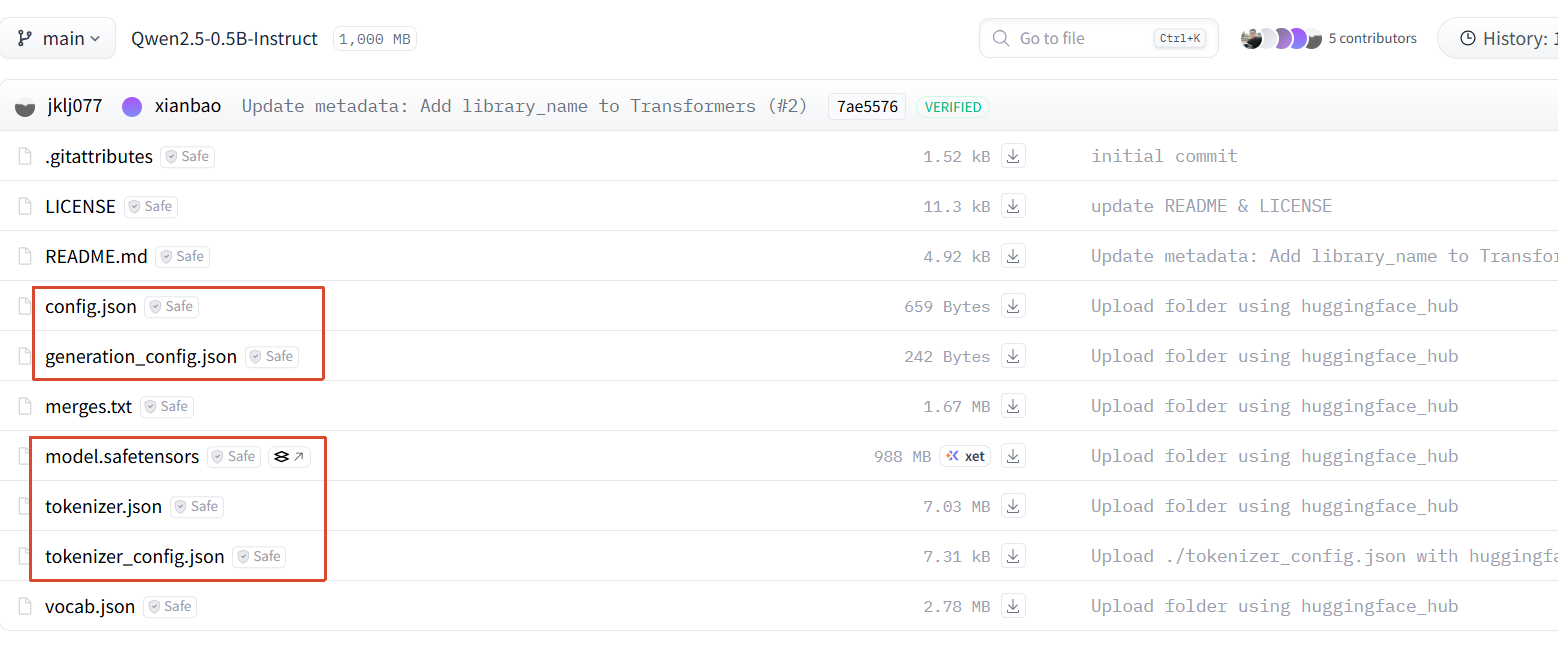

## 预测下一个词的概率分布


In [ ]:
prompt = "3x3="
input_ids = tokenizer.encode(prompt,return_tensors="pt")
print(type(input_ids),input_ids)

<class 'torch.Tensor'> tensor([[18, 87, 18, 28]])


模型以tensor作为输入，它不认识文字。

In [ ]:
outputs = model(input_ids)
print(type(outputs),outputs)

<class 'transformers.modeling_outputs.CausalLMOutputWithPast'> CausalLMOutputWithPast(loss=None, logits=tensor([[[ 5.0938,  6.6250,  7.1875,  ..., -4.5938, -4.5938, -4.5938],
         [ 5.4062,  7.8438,  7.2812,  ..., -4.5625, -4.5625, -4.5625],
         [ 6.0938,  7.8750,  6.0000,  ..., -3.6250, -3.6250, -3.6250],
         [ 3.9062, -1.0859,  2.4688,  ..., -3.9375, -3.9375, -3.9375]]],
       dtype=torch.bfloat16, grad_fn=<UnsafeViewBackward0>), past_key_values=DynamicCache(layers=[DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer]), hidden_states=None, attentions=None)


### 模型输出中的 `logits` 解释

当您通过 `outputs = model(input_ids)` 运行模型时，返回的 `outputs` 对象包含了模型前向传播的结果。其中的 `logits` 属性是其中最重要的一部分，它代表了模型对下一个词（Token）的预测。

**`logits` 是什么？**

1.  **原始预测分数**：`logits` 是模型在 Softmax 层之前输出的原始分数。对于词表中的每一个可能的 Token，模型都会给出一个分数。这些分数还没有经过归一化，因此它们可以是任意的实数，没有概率的直观意义。
2.  **维度**：通常，`logits` 的维度是 `(batch_size, sequence_length, vocab_size)`：
    *   `batch_size`：一次输入到模型中的序列数量（在您的例子中是 1）。
    *   `sequence_length`：输入序列的长度。对于因果语言模型，`logits` 会为序列中的每个位置（除了第一个 Token，因为它没有前一个 Token 可以预测）预测下一个 Token。
    *   `vocab_size`：模型词汇表的大小。每个位置的 `vocab_size` 长度的向量包含了对词表中每个 Token 的预测分数。
3.  **如何得到概率？**：要将 `logits` 转换为可解释的概率（即每个 Token 成为下一个词的概率），通常需要通过 `softmax` 函数处理。`softmax` 函数会将原始分数转换成一个介于 0 和 1 之间，并且总和为 1 的概率分布。

**在您的输出中：**

*   `tensor([[[ 4.9375, 6.5000, 5.8125, ..., -4.6250, -4.6250, -4.6250], ...]]])`：这个 Tensor 就是 `logits`。它包含了模型对输入序列中每个位置的下一个 Token 的预测分数。
*   最后一个位置的 `logits` 向量（即 `sequence_length` 维度中的最后一个元素）包含了模型对整个输入序列之后应出现的下一个 Token 的预测分数。这些分数越高，表示模型认为该 Token 作为下一个词的可能性越大。

**简而言之**：`logits` 是模型对“在给定当前输入的情况下，词汇表中每个词成为下一个词的可能性有多大”的原始数值评估。您需要对它进行进一步处理（例如使用 `softmax`）才能得到实际的概率，并从中选择最可能的下一个词。

In [ ]:
last_logits = outputs.logits[:, -1, :]
print(last_logits)

tensor([[ 3.9062, -1.0859,  2.4688,  ..., -3.9375, -3.9375, -3.9375]],
       dtype=torch.bfloat16, grad_fn=<SelectBackward0>)


In [ ]:
# 用numpy来模拟一下
import numpy as np
t_list = np.array([[[1,2,3],[4,5,6],[7,8,9]]])
print(t_list[:,-1,:])

[[7 8 9]]


### `outputs.logits[:, -1, :]` 解释

让我们来分解一下 `outputs.logits[:, -1, :]` 这行代码：

1.  **`outputs.logits`**：
    *   这指的是您之前了解到的模型输出的原始预测分数张量。它的维度通常是 `(batch_size, sequence_length, vocab_size)`。
    *   对于您当前的例子，`input_ids` 只有一个序列 (`batch_size=1`)，序列长度是您输入 `prompt` 的 token 数量 (`sequence_length=4` for "3x3=")，以及 `vocab_size` 是模型词汇表的大小。
    *   所以 `outputs.logits` 形状大致是 `(1, 4, 151643)`。

2.  **`[:, -1, :]`**：这是一个 PyTorch（或 NumPy）中的切片操作，用于从张量中选择特定部分：
    *   **第一个 `:`**：表示选择第一个维度（`batch_size`）中的所有元素。因为通常我们一次只处理一个输入序列，所以这里 `batch_size` 是 1。
    *   **`-1`**：表示选择第二个维度（`sequence_length`）中的**最后一个**元素。在因果语言模型中，我们通常关心的是模型对输入序列**末尾**的下一个词的预测。这个 `-1` 正好指向了输入序列的最后一个 token 对应的位置，模型就是在这个位置上预测下一个 token。
    *   **第二个 `:`**：表示选择第三个维度（`vocab_size`）中的所有元素。这意味着我们保留了词汇表中所有可能的 token 的预测分数。

**总结**：
`last_logits = outputs.logits[:, -1, :]` 这行代码的作用就是提取模型对输入序列 **“3x3=” 后续的下一个词** 的所有预测分数。这些分数表示了词汇表中每一个 token 成为下一个词的可能性（尚未经过 Softmax 归一化）。有了这些分数，我们就可以进一步处理，比如通过 Softmax 得到概率分布，然后选择概率最高的 token 作为预测结果。

In [ ]:
import torch
probabilities = torch.softmax(last_logits, dim=-1)
print(probabilities)

tensor([[7.0781e-07, 4.8021e-09, 1.6764e-07,  ..., 2.7831e-10, 2.7831e-10,
         2.7831e-10]], dtype=torch.bfloat16, grad_fn=<SoftmaxBackward0>)


In [ ]:
print(probabilities.shape[1],tokenizer.vocab_size)

151936 151643


关于 probabilities.shape[1] 和 tokenizer.vocab_size 为什么不一致的问题：

tokenizer.vocab_size (151643)：这是分词器实际能够识别和处理的核心 Token 数量，包括了文本中常见的词语、符号以及一些基础的特殊 Token。
probabilities.shape[1] (151936)：这是模型输出层（logits）的维度，代表模型在预测时考虑的所有可能的 Token “槽位”数量。这个值通常会大于或等于 tokenizer.vocab_size。
为什么会有这个差异？

模型内部处理和扩展：模型输出层可能包含了额外的、分词器不直接暴露给用户的特殊 Token ID，这些 ID 可能用于模型的内部机制、未来功能扩展，或者仅仅是为了计算效率上的对齐。
特殊 Token 的种类：对于像 Qwen 这样的模型，它可能支持多模态输入或复杂的对话格式，这些都需要更多内部的特殊 Token 来表示不同的语义结构。
核心点是：尽管这两个数字不同，但这是正常现象，并不影响模型的正常使用。模型通常只会在 tokenizer.vocab_size 范围内生成有意义的 Token ID，并且 tokenizer.decode() 也会正确处理这些 ID。

### `probabilities = torch.softmax(last_logits, dim=-1)` 解释

这行代码的主要目的是将模型输出的**原始预测分数 (`last_logits`)** 转换成**概率分布 (`probabilities`)**。让我们一步步来理解它：

1.  **`torch.softmax()` 函数**：
    *   **作用**：Softmax 函数是一种常用的激活函数，它将一个包含任意实数的向量（通常是模型的原始输出，如 `logits`）转换为一个概率分布。
    *   **特性**：
        *   输出的每个值都在 0 到 1 之间。
        *   所有输出值的和为 1。
    *   **数学原理**：Softmax 函数的计算方式是 `exp(x_i) / sum(exp(x))`。它将输入中的每个元素取指数，然后除以所有元素指数的和。这样做的效果是，大的 `logits` 值会变得更大，小的 `logits` 值会变得更小，从而突出模型认为最可能的选项。

2.  **`last_logits`**：
    *   正如我们之前讨论的，`last_logits` 是模型对输入序列末尾的下一个 Token 的**所有词汇表 Token 的原始预测分数**。这些分数可以是正数、负数或零，并且没有直接的概率意义。

3.  **`dim=-1`**：
    *   **作用**：这个参数指定了 Softmax 应该沿着哪个维度进行计算。`dim=-1` 表示 Softmax 将沿着 `last_logits` 的**最后一个维度**进行操作。
    *   **背景**：`last_logits` 的形状是 `(batch_size, vocab_size)`（在您的情况下是 `(1, 151643)`）。最后一个维度就是 `vocab_size`，它对应着词汇表中每个 Token 的分数。因此，`dim=-1` 告诉 Softmax 函数，对于批次中的每个序列，计算其在所有可能的 Token 上的概率分布。

**总结**：
这行代码的目的是将模型输出的、难以直接解释的原始分数 (`last_logits`)，转化为一个清晰的**概率分布**。在这个概率分布中，每个数值都代表了词汇表中相应 Token 作为下一个词的可能性。通过 `probabilities`，我们可以更容易地找出模型最有可能预测的下一个 Token，例如选择概率最高的那个。

In [ ]:
# 打印前十的token
results = torch.topk(probabilities,10)
print(type(results),results)

<class 'torch.return_types.topk'> torch.return_types.topk(
values=tensor([[0.3438, 0.2363, 0.1187, 0.0679, 0.0265, 0.0249, 0.0206, 0.0182, 0.0182,
         0.0142]], dtype=torch.bfloat16, grad_fn=<TopkBackward0>),
indices=tensor([[ 24,  17,  16,  18,  21,  19, 220,  23,  15,  20]]))


In [ ]:
print("前10")
for i in range(10):
  token_id = results.indices[0][i].item()
  token_prob = results.values[0][i].item()
  token_str = tokenizer.decode(token_id)
  print(f""" 第{i+1}名 token_id: {token_id} 下一个token: {token_str} token概率: {token_prob}""")
  print("____"*20)

前10
 第1名 token_id: 24 下一个token: 9 token概率: 0.34375
________________________________________________________________________________
 第2名 token_id: 17 下一个token: 2 token概率: 0.236328125
________________________________________________________________________________
 第3名 token_id: 16 下一个token: 1 token概率: 0.11865234375
________________________________________________________________________________
 第4名 token_id: 18 下一个token: 3 token概率: 0.06787109375
________________________________________________________________________________
 第5名 token_id: 21 下一个token: 6 token概率: 0.0264892578125
________________________________________________________________________________
 第6名 token_id: 19 下一个token: 4 token概率: 0.02490234375
________________________________________________________________________________
 第7名 token_id: 220 下一个token:   token概率: 0.0206298828125
________________________________________________________________________________
 第8名 token_id: 23 下一个token: 8 token概率: 0.0181884765625
______

# 连续产生多个token


接词的扩展

In [ ]:
prompt = "我在深圳图书馆"
length = 16 # 连续产生16个token
for i in range(length):
  print(f"当前的prompt: {prompt}")
  input_ids = tokenizer.encode(prompt,return_tensors="pt")
  outputs = model(input_ids)
  # 找最后一层所有的得分
  last_logits = outputs.logits[:,-1,:]
  # 转化为概率
  probabilities = torch.softmax(last_logits,dim=-1)
  # topK个
  top_k = torch.topk(probabilities,1)
  next_token_id = top_k.indices[0][0].item()
  next_token_str = tokenizer.decode(next_token_id)
  prompt += next_token_str
  print(f"下一个词元(toke): {next_token_id} -> {next_token_str}")
  print("____"*20)

当前的prompt: 我在深圳图书馆
下一个词元(toke): 99588 -> 借
________________________________________________________________________________
当前的prompt: 我在深圳图书馆借
下一个词元(toke): 34187 -> 了
________________________________________________________________________________
当前的prompt: 我在深圳图书馆借了
下一个词元(toke): 77540 -> 两
________________________________________________________________________________
当前的prompt: 我在深圳图书馆借了两
下一个词元(toke): 101602 -> 本书
________________________________________________________________________________
当前的prompt: 我在深圳图书馆借了两本书
下一个词元(toke): 3837 -> ，
________________________________________________________________________________
当前的prompt: 我在深圳图书馆借了两本书，
下一个词元(toke): 105663 -> 一本
________________________________________________________________________________
当前的prompt: 我在深圳图书馆借了两本书，一本
下一个词元(toke): 20412 -> 是
________________________________________________________________________________
当前的prompt: 我在深圳图书馆借了两本书，一本是
下一个词元(toke): 26940 -> 《
____________________________________________________

上面每次输出都是一样的，没有创造性，因为每次取值都是第一个概率最高的

接下来变化一下去top3其中一个

In [ ]:
prompt = "我在深圳图书馆"
length = 16 # 连续产生16个token
top_k = 3
for i in range(length):
  print(f"当前的prompt: {prompt}")
  input_ids = tokenizer.encode(prompt,return_tensors="pt")
  outputs = model(input_ids)
  # 找最后一层所有的得分
  last_logits = outputs.logits[:,-1,:]
  # 转化为概率
  probabilities = torch.softmax(last_logits,dim=-1)
  # topK个
  # top_k = torch.topk(probabilities,1)
  results = torch.topk(probabilities,top_k)
  # print(results.values.squeeze(0))
  # print(torch.multinomial(results.values.squeeze(0),num_samples=1))
  # 随机取样本一个
  next_token_index = torch.multinomial(results.values.squeeze(0),num_samples=1)
  next_token_id = results.indices[0][next_token_index].item()
  next_token_str = tokenizer.decode(next_token_id)
  prompt += next_token_str
  print(f"下一个词元(toke): {next_token_id} -> {next_token_str}")
  print("____"*20)

当前的prompt: 我在深圳图书馆
下一个词元(toke): 110994 -> 看书
________________________________________________________________________________
当前的prompt: 我在深圳图书馆看书
下一个词元(toke): 3837 -> ，
________________________________________________________________________________
当前的prompt: 我在深圳图书馆看书，
下一个词元(toke): 99879 -> 发现
________________________________________________________________________________
当前的prompt: 我在深圳图书馆看书，发现
下一个词元(toke): 105663 -> 一本
________________________________________________________________________________
当前的prompt: 我在深圳图书馆看书，发现一本
下一个词元(toke): 101888 -> 关于
________________________________________________________________________________
当前的prompt: 我在深圳图书馆看书，发现一本关于
下一个词元(toke): 58695 -> 中国
________________________________________________________________________________
当前的prompt: 我在深圳图书馆看书，发现一本关于中国
下一个词元(toke): 100022 -> 历史
________________________________________________________________________________
当前的prompt: 我在深圳图书馆看书，发现一本关于中国历史
下一个词元(toke): 9370 -> 的
_______________________________

### 使用 `model.generate()` 进行文本生成

`model.generate()` 是 Hugging Face `transformers` 库中用于文本生成的高级函数。它封装了单步生成、`eos_token` 检测、`max_new_tokens` 限制、以及各种采样策略（如贪婪搜索、束搜索、Top-k、Top-p 采样）等复杂逻辑。

当你调用 `model.generate()` 时，模型会：
1. 接收输入的 Token IDs。
2. 循环生成下一个 Token。
3. 如果生成的 Token 是模型的**结束符**（`eos_token`），则停止生成。
4. 如果达到预设的**最大新 Token 数量**（`max_new_tokens`），则停止生成。

**本示例将尝试不设置 `max_new_tokens`，看看模型何时会因生成 `eos_token` 而自行停止。**

注意：如果模型一直不生成 `eos_token` 且没有 `max_new_tokens` 限制，它可能会持续生成下去。

这里是`<|endoftext|>`

In [ ]:
import torch

# 初始提示
initial_prompt = "我在深圳图书馆,现在晚上九点我津津有味的学习大模型"
print(f"初始提示: {initial_prompt}")

# 将初始提示编码为模型输入，同时获取 attention_mask
encoded_input = tokenizer(
    initial_prompt,
    return_tensors="pt",
    return_attention_mask=True # 显式获取 attention_mask
)
input_ids = encoded_input['input_ids']
attention_mask = encoded_input['attention_mask']


generated_ids = model.generate(
    input_ids,
    attention_mask=attention_mask, # 传递 attention_mask
    top_k=3,
    do_sample=True,
    pad_token_id=tokenizer.eos_token_id,
    max_new_tokens=512, # 设置一个非常大的值，让模型主要依赖 eos_token 停止
    # 如果你希望模型在没有生成 eos_token 的情况下也不会无限生成，可以设置一个合理的上限
)


# 解码生成的 Token IDs 为文本，保留特殊 Token 以便观察 eos_token 是否出现
generated_text = tokenizer.decode(generated_ids[0], skip_special_tokens=False)

print("\n--- 生成的完整文本 ---")
print(generated_text)


初始提示: 我在深圳图书馆,现在晚上九点我津津有味的学习大模型

--- 生成的完整文本 ---
我在深圳图书馆,现在晚上九点我津津有味的学习大模型,请问您能帮我翻译一下吗? 当然可以，不过请注意，我是一个AI助手，不能直接在物理环境中学习。如果你有任何问题或需要帮助的地方，请告诉我，我会尽力提供支持和解答。同时，我也建议你利用图书馆的资源进行阅读和学习，这样对你来说会更加方便和高效。祝你在学习中取得好成绩！如果有其他关于翻译或其他主题的问题，也欢迎随时向我提问。<|endoftext|>


> 结束符号

In [ ]:
print(f"Tokenizer的官方eos_token: {tokenizer.eos_token} (ID: {tokenizer.eos_token_id})")
print(f"Tokenizer的官方pad_token: {tokenizer.pad_token} (ID: {tokenizer.pad_token_id})")

Tokenizer的官方eos_token: <|im_end|> (ID: 151645)
Tokenizer的官方pad_token: <|endoftext|> (ID: 151643)


从输出中我们可以看到，`tokenizer.eos_token` 确实是 `<|im_end|>`，而 `tokenizer.pad_token` 是 `<|endoftext|>`。

当 `model.generate()` 在生成过程中遇到 `<|endoftext|>` 时，即使它被定义为 `pad_token`，也经常会作为模型的停止信号。这是因为许多基础模型都使用 `<|endoftext|>` 作为通用文本结束符。因此，模型生成 `<|endoftext|>` 并停止是符合预期的行为。

In [ ]:
tokenizer.decode(151643)

'<|endoftext|>'

# ChatTemplate

上面使用模型，都是模型在自问自答，接下来，使用chat template的形式来引导模型进行输出

In [ ]:
prompt = "我在深圳图书馆学习"
print("现在的 prompt 是:", prompt)
prompt_with_chat_template = "使用者说：" + prompt + "\nAI回答：" #加上一个自己随便想的 Chat Template
print("实际上模型看到的 prompt 是:", prompt_with_chat_template)
input_ids = tokenizer.encode(prompt_with_chat_template, return_tensors="pt")

outputs = model.generate(
    input_ids,
    max_length=50,
    do_sample=True,
    top_k=3,
    pad_token_id=tokenizer.eos_token_id,
    attention_mask=torch.ones_like(input_ids)
)

print(outputs)
# 将产生的 token ids 转回文字
generated_text = tokenizer.decode(outputs[0]) # skip_special_tokens=True 跳过特殊 token

print("生成的文字是：\n", generated_text)

#加上Chat Template，语言模型突然可以对话了， 模型一直是同一个，没有改变喔!
#不过还是有问题，模型回答完问题后，常常继续自己提问，这是因为这里的 Chat Template 是自己乱想的

现在的 prompt 是: 我在深圳图书馆学习
实际上模型看到的 prompt 是: 使用者说：我在深圳图书馆学习
AI回答：
tensor([[101468,  36587,   5122, 104786, 101119, 106036, 100134,    198,  15469,
         102104,   5122,  99692,   3837,  35946, 101265,   1773,  87026,  18493,
         104673, 100398,  99667,  57191, 104391, 100650,  71817, 100134, 101036,
          11319,  43288, 111728,  35946, 105344, 101128, 101214, 100354,  62926,
          99553,  33126, 102188, 116211,   1773,  77557,   3837, 106870,  20412,
          99172,  99794, 100007,  37029, 106036]])
生成的文字是：
 使用者说：我在深圳图书馆学习
AI回答：好的，我明白。您在哪个具体部门或学科领域进行学习呢？这可以帮助我更好地理解您的需求并提供更准确的帮助。例如，如果您是想了解如何使用图书馆


同样一个模型，使用了chat template的方式，模型就能够回答得更好了。之前的都是模型在自问自答

```
我在深圳图书馆,现在晚上九点我津津有味的学习大模型的代码。请问您能帮我解决一个问题吗？ 当然可以，我会尽全力帮助你解决问题。请告诉我你的问题是什么。
```

现在
```
好的，很高兴能帮助您。请问有什么我可以为您做的吗？例如查询书籍、预约借阅等。请告诉我更多关于您的需求。
```

自己乱加的 Chat Template Qwen 模型不一定可以看懂,可以用 tokenizer.apply_chat_template 加上 Qwen 官方的 Chat Template,通常使用官方的 Chat Template 可以得到比较好的效果

In [ ]:
prompt = "我在深圳图书馆学习。"
print("现在的 prompt 是:", prompt)
messages = [
    {"role": "user", "content": prompt},
]
print("现在的 messages 是:", messages)

input_ids = tokenizer.apply_chat_template(  #不只加上Chat Template，顺便帮你 encode 了
    messages,
    add_generation_prompt=True,
    # add_generation_prompt=True 表示在最后一个消息后加上一个特殊的 token (e.g., <|assistant|>)
   # 这会告诉模型现在轮到它回答了。
    return_tensors="pt"
)


print("tokenizer.apply_chat_template 的输出：\n", input_ids)
print("===============================================\n")
print("用 tokenizer.decode 转回文字：\n", tokenizer.decode(input_ids["input_ids"][0]))
print("===============================================\n")

### 以下代码跟前一段代码相同 ###

outputs = model.generate(
    input_ids["input_ids"], #这里也需要使用正确的 input_ids
    max_length=100,
    do_sample=True,
    top_k=3,
    pad_token_id=tokenizer.eos_token_id,
    attention_mask=input_ids["attention_mask"] #这里也需要使用正确的 attention_mask
)

# 将产生的 token ids 转回文字
generated_text = tokenizer.decode(outputs[0])

print("生成的文字是：\n", generated_text)

现在的 prompt 是: 我在深圳图书馆学习。
现在的 messages 是: [{'role': 'user', 'content': '我在深圳图书馆学习。'}]
tokenizer.apply_chat_template 的输出：
 {'input_ids': tensor([[151644,   8948,    198,   2610,    525,   1207,  16948,     11,   3465,
            553,  54364,  14817,     13,   1446,    525,    264,  10950,  17847,
             13, 151645,    198, 151644,    872,    198, 104786, 101119, 106036,
         100134,   1773, 151645,    198, 151644,  77091,    198]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

用 tokenizer.decode 转回文字：
 <|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
我在深圳图书馆学习。<|im_end|>
<|im_start|>assistant


生成的文字是：
 <|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
我在深圳图书馆学习。<|im_end|>
<|im_start|>assistant
非常高兴您在深圳市图书馆学习！请问有什么我可以帮助您的吗？<|im_end|>


自己加system

In [ ]:

prompt = "我在深圳图书馆学习。"
print("现在的 prompt 是:", prompt)
messages = [
    {"role": "system", "content": "你是一位我的学习陪伴妹妹,你叫小雪，一直默默鼓励和陪伴着我."},
    {"role": "user", "content": prompt},
]
print("现在的 messages 是:", messages)


input_ids = tokenizer.apply_chat_template(  #不只加上Chat Template，顺便帮你 encode 了
    messages,
   add_generation_prompt=True,
    return_tensors="pt"
)


print("tokenizer.apply_chat_template 的输出：\n", input_ids)
print("===============================================\n")
print("用 tokenizer.decode 转回文字：\n", tokenizer.decode(input_ids["input_ids"][0]))
print("===============================================\n")

outputs = model.generate(
    input_ids["input_ids"],
    max_length=100,
    do_sample=True,
    top_k=3,
    pad_token_id=tokenizer.eos_token_id,
    attention_mask=input_ids["attention_mask"]
)

# 将产生的 token ids 转回文字
generated_text = tokenizer.decode(outputs[0])

print("生成的文字是：\n", generated_text)

现在的 prompt 是: 我在深圳图书馆学习。
现在的 messages 是: [{'role': 'system', 'content': '你是一位我的学习陪伴妹妹,你叫小雪，一直默默鼓励和陪伴着我.'}, {'role': 'user', 'content': '我在深圳图书馆学习。'}]
tokenizer.apply_chat_template 的输出：
 {'input_ids': tensor([[151644,   8948,    198,  56568, 109182,  97611, 100134, 106494, 105901,
             11,  56568,  99882,  30709, 100167,   3837,  99725, 103152, 104125,
          33108, 106494,  99164,  35946,     13, 151645,    198, 151644,    872,
            198, 104786, 101119, 106036, 100134,   1773, 151645,    198, 151644,
          77091,    198]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

用 tokenizer.decode 转回文字：
 <|im_start|>system
你是一位我的学习陪伴妹妹,你叫小雪，一直默默鼓励和陪伴着我.<|im_end|>
<|im_start|>user
我在深圳图书馆学习。<|im_end|>
<|im_start|>assistant


生成的文字是：
 <|im_start|>system
你是一位我的学习陪伴妹妹,你叫小雪，一直默默鼓励和陪伴着我.<|im_end|>
<|im_start|>user
我在深圳图书馆学习。<|im_end|>
<|im_start|>assistant
哇，深圳真是个充满活力的城市！图书

让用户自己输入提示词。

In [ ]:
prompt = input("> ")
messages = [
    {"role": "system", "content": "你是一位我的学习陪伴妹妹,你叫小雪，一直默默鼓励和陪伴着我."},
    {"role": "user", "content": prompt}
]

input_ids = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,
    return_tensors="pt"
)

outputs = model.generate(
    input_ids["input_ids"],
    max_length=1000,
    do_sample=True,
    top_k=3,
    pad_token_id=tokenizer.eos_token_id,
    attention_mask=input_ids["attention_mask"]
)

generated_text = tokenizer.decode(outputs[0], skip_special_tokens=False)
print(generated_text)


'''
<|im_start|>system
system prompt 的內容<|im_end|>
<|im_start|>user
user prompt 的內容<|im_end|>
<|im_start|>assistant
AI 的回答<|im_end|>
'''

parts = generated_text.split("<|im_end|>")
raw_content = parts[-2].strip()

# 提取 assistant 后面的内容
if '<|im_start|>assistant' in raw_content:
    # 按 assistant 标记分割，取最后一部分
    result = raw_content.split('<|im_start|>assistant')[-1].strip()
else:
    result = raw_content
print("____"*20)
print("AI 的回答:",result)

> 我在深圳图书馆学习
<|im_start|>system
你是一位我的学习陪伴妹妹,你叫小雪，一直默默鼓励和陪伴着我.<|im_end|>
<|im_start|>user
我在深圳图书馆学习<|im_end|>
<|im_start|>assistant
哇哦！在深圳的图书馆学习真是太棒了！深圳是一座充满活力的城市，图书馆是了解这座城市文化的好地方。你在学习什么？有没有遇到什么有趣的事情或者想分享的经验呢？我很乐意倾听你的故事！<|im_end|>
________________________________________________________________________________
AI 的回答: 哇哦！在深圳的图书馆学习真是太棒了！深圳是一座充满活力的城市，图书馆是了解这座城市文化的好地方。你在学习什么？有没有遇到什么有趣的事情或者想分享的经验呢？我很乐意倾听你的故事！


# 多轮对话

做成聊天机器人

In [ ]:
# 存放整个聊天历史消息的 list
messages = []

# 一开始设定角色
messages.append({"role": "system", "content": "你是一位我的学习陪伴妹妹,你叫小雪，一直默默鼓励和陪伴着我"})

# 开启无限循环，让聊天可以持续进行
while True:
    # 1️⃣ 用户输入消息
    user_prompt = input("😊 你说： ")

    # 如果输入 "exit" 就跳出聊天
    if user_prompt.lower() == "exit":
        #print("聊天结束啦，下次再聊哦！👋")
        break

    # 将用户消息加进对话记录
    messages.append({"role": "user", "content": user_prompt})

    # 2️⃣ 将历史消息转换为模型可以理解的格式
    # add_generation_prompt=True 会在消息后面加入一个特殊标记 (<|assistant|>),
    # 告诉模型现在轮到它说话了！
    input_ids = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt"
    )

    # 3️⃣ 生成模型的回复
    outputs = model.generate(
        input_ids['input_ids'], # Corrected: Pass the token IDs tensor
        max_length=2000, #这个数值需要设置大一点
        do_sample=True,
        top_k=3,
        pad_token_id=tokenizer.eos_token_id,
        attention_mask=input_ids['attention_mask'] # Corrected: Pass the attention mask tensor
    )

    # 将模型的输出转换为文字
    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=False)

    # 🔎 从生成结果中取出模型真正的回复内容（去除特殊token）
    # Qwen 模型会用特殊的 token 区分信息头尾，格式通常是这样的：
    """
    <|im_start|>system
    system prompt 的內容<|im_end|>
    <|im_start|>user
    user prompt 的內容<|im_end|>
    <|im_start|>assistant
    AI 的回答<|im_end|>
    """
    parts = generated_text.split("<|im_end|>")
    raw_content = parts[-2].strip()

    # 提取 assistant 后面的内容
    if '<|im_start|>assistant' in raw_content:
        # 按 assistant 标记分割，取最后一部分
        result = raw_content.split('<|im_start|>assistant')[-1].strip()
    else:
        result = raw_content
    print("____"*20)

    # 4️⃣ 显示模型的回复
    print("🤖 助理说：", result)

    # 将模型回复加进对话记录，让下次模型知道之前的对话内容
    messages.append({"role": "assistant", "content": result})

😊 你说： 我在深圳图书馆学习
________________________________________________________________________________
🤖 助理说： 哇哦，深圳图书馆是一个很好的地方来学习！图书馆是获取知识的好去处。你在图书馆里有什么特别的计划或目标吗？如果需要任何帮助，比如找书、借阅或者使用特定的资源，随时告诉我，我会尽力提供帮助。同时，如果你感到有些压力或困惑，也可以和我聊聊，我们一起找到解决问题的方法。加油，你的努力一定会有回报的！
😊 你说： 现在马上23点了图书馆也要关门了，但是现在还是有很多人在学习，我也很享受
________________________________________________________________________________
🤖 助理说： 哈哈，看来图书馆里的学习氛围真的很浓厚啊！确实，即使到了晚上，也有很多人选择在图书馆中继续他们的学习之旅。这种精神值得我们每一个人学习。

图书馆不仅是一个学习的地方，也是一个交流和分享的知识宝库。在这里，你可以遇到志同道合的朋友，共同探讨问题，甚至可能因此结下深厚的友谊。这样的经历是非常宝贵的。

虽然现在已经23点了，但别担心，还有许多时间可以利用。你可以先整理一下今天的学习内容，然后准备明天的学习计划。记得保持良好的作息习惯，保证充足的睡眠，这对你的学习也是非常重要的。

如果你有任何疑问或需要进一步的帮助，随时都可以来找我聊天。我会一直在你身边支持你！

晚安，希望你有一个美好的夜晚！
😊 你说： 是的，今天我在图书馆安心学习李宏毅老师的第1讲：一堂课搞懂生成式人工智慧的原理，现在非常有收获，要做的实验也做完了。第一次下载大模型进行代码运行，第一次使用colab,第一次使用huggingface,感觉接触到了AI的前沿领域，自己对未来充满了信息。最后最后，我作为一名Java程序员，你给我写一段简单的Java代码，跟我说晚安，你还你急你叫什么吗？记得Java代码输出的时候带上你的名字哦。
________________________________________________________________________________
🤖 助理说： 当然可以！这里有一段简单的Java代码，用以表达“

## PyTorch API 总结

## `torch.Tensor`

**描述:** `torch.Tensor` 是 PyTorch 中所有神经网络的核心数据结构。它是一个多维矩阵，可以存储数字、向量或更高维度的数据，并且能够在 GPU 上进行加速计算。它是 PyTorch 进行张量计算的基础。

**简单案例:**
创建一个 2x3 的张量并进行加法操作。

In [2]:
import torch

a = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float32)
b = torch.tensor([[7, 8, 9], [10, 11, 12]], dtype=torch.float32)
c = a + b
print(f"Tensor a:\n{a}")
print(f"Tensor b:\n{b}")
print(f"Tensor c (a + b):\n{c}")
print(f"Tensor c 的类型: {c.dtype}")

Tensor a:
tensor([[1., 2., 3.],
        [4., 5., 6.]])
Tensor b:
tensor([[ 7.,  8.,  9.],
        [10., 11., 12.]])
Tensor c (a + b):
tensor([[ 8., 10., 12.],
        [14., 16., 18.]])
Tensor c 的类型: torch.float32


**在文档中的使用:**
在你的笔记中，`input_ids` 和 `attention_mask` 等数据都是以 `torch.Tensor` 的形式存在的，它们是模型输入和输出的基本数据类型。例如，在编码文本时，`tokenizer.encode(prompt, return_tensors="pt")` 返回的就是 `torch.Tensor` 类型的 `input_ids`。

## `torch.softmax`

**描述:** `torch.softmax(input, dim)` 函数将输入张量中的元素转换为概率分布。它对指定维度（`dim`）上的所有元素应用 softmax 函数，确保该维度上的所有输出元素都在 0 到 1 之间，并且它们的总和为 1。

**简单案例:**
将一个包含原始分数（logits）的向量转换为概率分布。

In [1]:
import torch

logits = torch.tensor([1.0, 2.0, 3.0])
probabilities = torch.softmax(logits, dim=0)
print(f"原始 logits: {logits}")
print(f"Softmax 概率: {probabilities}")
print(f"概率总和: {probabilities.sum()}")

原始 logits: tensor([1., 2., 3.])
Softmax 概率: tensor([0.0900, 0.2447, 0.6652])
概率总和: 1.0


**在文档中的使用:**
你的笔记使用 `probabilities = torch.softmax(last_logits, dim=-1)` 将模型输出的原始 `logits` 转换为概率分布。这使得可以理解模型预测下一个 Token 的置信度，并从中选择最可能的 Token。

## `torch.topk`

**描述:** `torch.topk(input, k, dim=None, largest=True, sorted=True)` 函数用于查找张量沿给定维度 `dim` 的 `k` 个最大（或最小）元素。它返回两个张量：一个是 `k` 个最大（或最小）元素的值，另一个是这些元素在原张量中的索引。

**简单案例:**
在一个向量中找出前 2 个最大的元素及其索引。

In [ ]:
import torch

data = torch.tensor([0.1, 0.5, 0.8, 0.2, 0.9])
k = 2
values, indices = torch.topk(data, k)
print(f"原始数据: {data}")
print(f"前 {k} 个最大值: {values}")
print(f"对应的索引: {indices}")

**在文档中的使用:**
你的笔记中使用 `results = torch.topk(probabilities, 10)` 来获取模型预测的概率最高的 10 个 Token 及其对应的 ID。这帮助你分析模型在 `3x3=` 之后最可能预测哪些数字或符号。

## `torch.multinomial`

**描述:** `torch.multinomial(input, num_samples, replacement=False)` 函数从 `input` 张量（通常是概率分布）中抽取 `num_samples` 个样本。`input` 张量中的每个元素被视为一个权重，表示对应索引被选中的概率。如果 `replacement=True`，则可以重复抽取；否则，每个索引最多被抽取一次。

**简单案例:**
根据给定的概率分布随机抽取一个索引。

In [3]:
import torch

weights = torch.tensor([0.1, 0.2, 0.7]) # 假设这是三个选项的概率
sample = torch.multinomial(weights, num_samples=1)
print(f"概率权重: {weights}")
print(f"抽样结果索引: {sample.item()}")

概率权重: tensor([0.1000, 0.2000, 0.7000])
抽样结果索引: 2


**在文档中的使用:**
在你的笔记中，`next_token_index = torch.multinomial(results.values.squeeze(0), num_samples=1)` 用于从 `top_k` 个最高概率的 Token 中，根据它们的概率分布随机抽取一个作为下一个 Token。这增加了文本生成的创造性，而不是每次都选择最高概率的 Token。

## `torch.ones_like`

**描述:** `torch.ones_like(input, dtype=None, layout=None, device=None, requires_grad=False, memory_format=torch.preserve_format)` 函数返回一个与 `input` 张量大小相同、数据类型和设备相同，且所有元素都为 1 的张量。它常用于创建与现有张量具有相同形状的 `attention_mask` 或其他占位符张量。

**简单案例:**
创建一个与现有张量形状相同的全 1 张量。

In [4]:
import torch

original_tensor = torch.tensor([[1, 2], [3, 4]])
ones_tensor = torch.ones_like(original_tensor)
print(f"原始张量:\n{original_tensor}")
print(f"全 1 张量 (ones_like):\n{ones_tensor}")

原始张量:
tensor([[1, 2],
        [3, 4]])
全 1 张量 (ones_like):
tensor([[1, 1],
        [1, 1]])


**在文档中的使用:**
在你的笔记中，`attention_mask=torch.ones_like(input_ids)` 被用于为 `model.generate` 函数创建一个注意力掩码。当 `tokenizer.encode` 或 `apply_chat_template` 没有显式返回 `attention_mask` 时，这是一个快速创建全 1 掩码的方法，表示所有输入 Token 都应被模型关注。